# 06 Anomaly Detection

This notebook analyses potential anomalies in the AquaSensor dissolved oxygen dataset.

The anomaly detection approach uses rule-based indicators created during preprocessing:

- Normal readings
- Possible biofouling / isolated low dissolved oxygen
- Possible sensor power or communication gap
- Possible pollution event affecting multiple sensors

The purpose is to identify unusual water quality patterns and support interpretation of dissolved oxygen behaviour.



Cell 1 — Markdown
Cell 2 — Imports
Cell 3 — Load Final Modelling Dataset
Cell 4 — Check Anomaly Columns
Cell 5 — Define Anomaly Labels
Cell 6 — Anomaly Counts
Cell 7 — Anomaly Percentage
Cell 8 — Anomaly Counts by Sensor
Cell 9 — Pollution Alert Summary
Cell 10 — Plot Anomaly Counts
Cell 11 — Plot Low DO Events Over Time
Cell 12 — Plot DO with Anomaly Points by Sensor
Cell 13 — Extract Anomaly Records
Cell 14 — Save Anomaly Results
Cell 15 — Summary

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../data/processed/aquasensor_final.csv"
ANOMALY_OUTPUT = "../data/processed/anomaly_detection_results.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"], low_memory=False)

print("Dataset loaded")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

df.head()

Dataset loaded
Rows: 107974
Columns: 32
Start: 2023-10-30 00:00:00
End: 2026-06-04 21:13:40


,timestamp,sensor_id,sensor_name,temperature,dissolved_oxygen_mgl,dissolved_oxygen_pct,air_temperature_c,sunshine_wm2,cloud_cover_pct,hour,...,do_mgl_next_60min,do_pct_next_60min,do_mgl_next_75min,do_pct_next_75min,do_mgl_next_90min,do_pct_next_90min,do_mgl_next_105min,do_pct_next_105min,do_mgl_next_120min,do_pct_next_120min
0,2025-06-01 00:04:48,941115,Derwent 13-50,13.0,9.7,91.2,11.3,0.0,17.0,0.0,...,9.7,90.5,9.6,90.4,9.6,90.2,9.6,90.1,9.6,89.9
1,2025-06-01 00:16:44,941115,Derwent 13-50,12.9,9.7,91.1,11.3,0.0,17.0,0.0,...,9.6,90.4,9.6,90.2,9.6,90.1,9.6,89.9,9.6,89.8
2,2025-06-01 00:28:41,941115,Derwent 13-50,12.9,9.7,90.9,11.3,0.0,17.0,0.0,...,9.6,90.2,9.6,90.1,9.6,89.9,9.6,89.8,9.6,89.7
3,2025-06-01 00:40:37,941115,Derwent 13-50,12.8,9.7,90.7,11.3,0.0,17.0,0.0,...,9.6,90.1,9.6,89.9,9.6,89.8,9.6,89.7,9.6,89.6
4,2025-06-01 00:52:33,941115,Derwent 13-50,12.8,9.7,90.5,11.3,0.0,17.0,0.0,...,9.6,89.9,9.6,89.8,9.6,89.7,9.6,89.6,9.6,89.5


In [3]:
required_cols = [
    "timestamp",
    "sensor_id",
    "sensor_name",
    "dissolved_oxygen_mgl",
    "dissolved_oxygen_pct",
    "pollution_alert",
    "anomaly_type",
]

missing = [col for col in required_cols if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("All required anomaly columns are present.")

All required anomaly columns are present.


In [4]:
anomaly_labels = {
    0: "Normal",
    1: "Possible Biofouling / Isolated Low DO",
    2: "Possible Battery or Communication Gap",
    3: "Possible Pollution Event",
}

df["anomaly_label"] = df["anomaly_type"].map(anomaly_labels)

df[["timestamp", "sensor_name", "dissolved_oxygen_mgl", "pollution_alert", "anomaly_type", "anomaly_label"]].head()

,timestamp,sensor_name,dissolved_oxygen_mgl,pollution_alert,anomaly_type,anomaly_label
0,2025-06-01 00:04:48,Derwent 13-50,9.7,0,0,Normal
1,2025-06-01 00:16:44,Derwent 13-50,9.7,0,0,Normal
2,2025-06-01 00:28:41,Derwent 13-50,9.7,0,0,Normal
3,2025-06-01 00:40:37,Derwent 13-50,9.7,0,0,Normal
4,2025-06-01 00:52:33,Derwent 13-50,9.7,0,0,Normal


In [5]:
anomaly_counts = (
    df["anomaly_label"]
    .value_counts()
    .reset_index()
)

anomaly_counts.columns = ["anomaly_label", "count"]
anomaly_counts

,anomaly_label,count
0,Normal,107666
1,Possible Biofouling / Isolated Low DO,231
2,Possible Battery or Communication Gap,77


In [6]:
anomaly_summary = anomaly_counts.copy()
anomaly_summary["percentage"] = (
    anomaly_summary["count"] / len(df) * 100
).round(3)

anomaly_summary

,anomaly_label,count,percentage
0,Normal,107666,99.715
1,Possible Biofouling / Isolated Low DO,231,0.214
2,Possible Battery or Communication Gap,77,0.071


In [7]:
sensor_anomaly_counts = (
    df.groupby(["sensor_name", "anomaly_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["sensor_name", "count"], ascending=[True, False])
)

sensor_anomaly_counts

,sensor_name,anomaly_label,count
0,Derwent 13,Normal,41184
2,Derwent 13,Possible Biofouling / Isolated Low DO,231
1,Derwent 13,Possible Battery or Communication Gap,45
3,Derwent 13-50,Normal,33671
4,Derwent 13-50,Possible Battery or Communication Gap,19
5,Derwent 21,Normal,32811
6,Derwent 21,Possible Battery or Communication Gap,13


In [8]:
pollution_summary = (
    df.groupby("sensor_name")["pollution_alert"]
    .agg(["sum", "count"])
    .reset_index()
)

pollution_summary["pollution_alert_percentage"] = (
    pollution_summary["sum"] / pollution_summary["count"] * 100
).round(3)

pollution_summary = pollution_summary.rename(
    columns={
        "sum": "pollution_alert_count",
        "count": "total_readings",
    }
)

pollution_summary

,sensor_name,pollution_alert_count,total_readings,pollution_alert_percentage
0,Derwent 13,231,41460,0.557
1,Derwent 13-50,0,33690,0.000
2,Derwent 21,0,32824,0.000


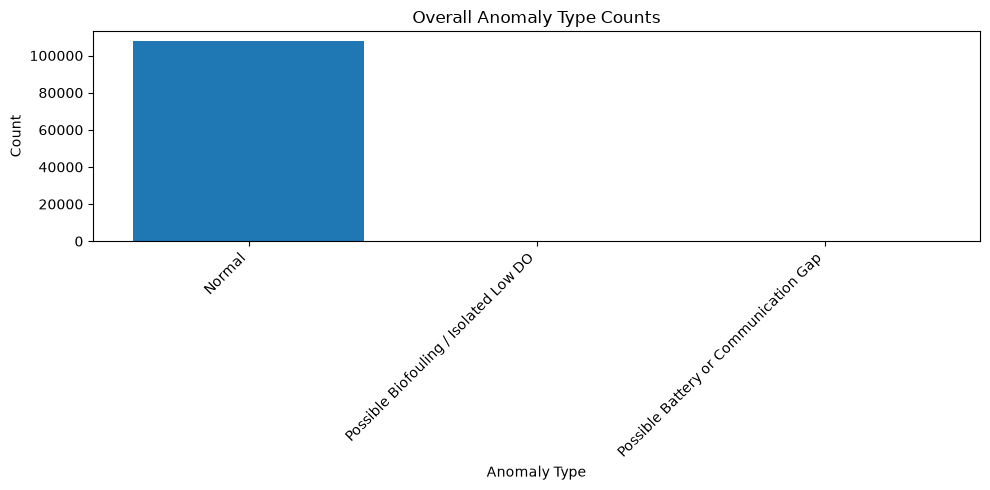

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(anomaly_summary["anomaly_label"], anomaly_summary["count"])
plt.xlabel("Anomaly Type")
plt.ylabel("Count")
plt.title("Overall Anomaly Type Counts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

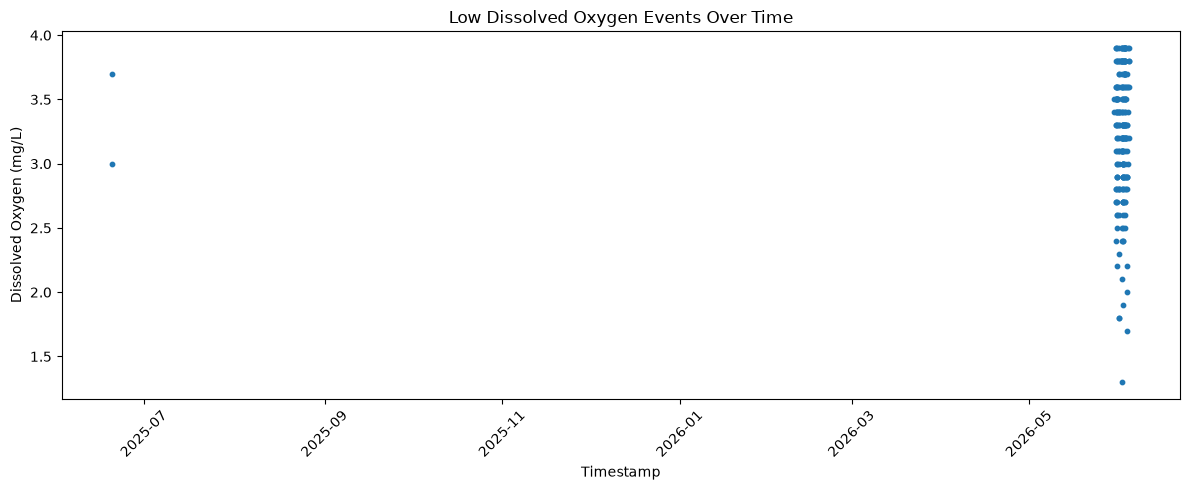

In [10]:
low_do = df[df["pollution_alert"] == 1].copy()

plt.figure(figsize=(12, 5))
plt.scatter(low_do["timestamp"], low_do["dissolved_oxygen_mgl"], s=10)
plt.xlabel("Timestamp")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.title("Low Dissolved Oxygen Events Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

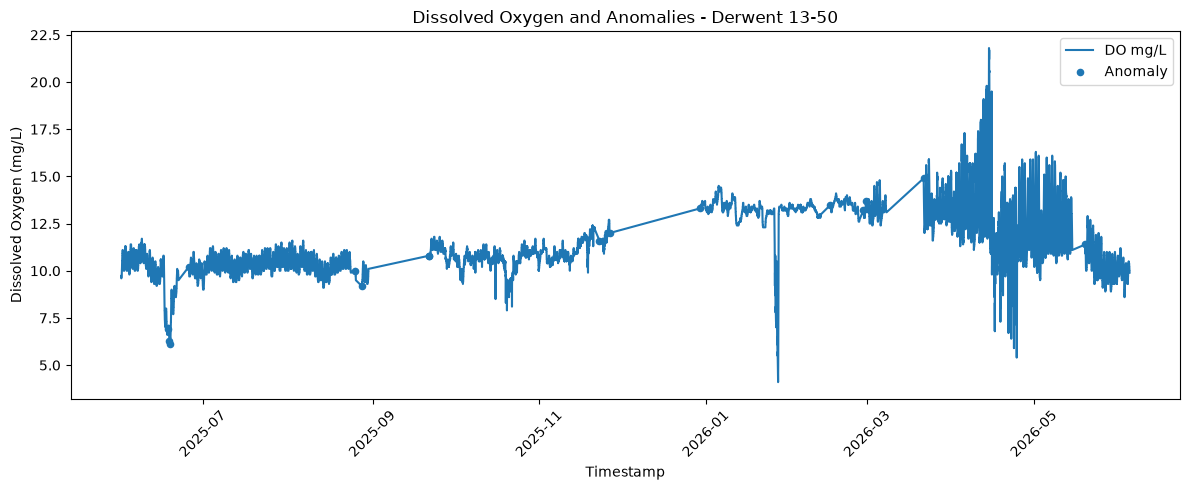

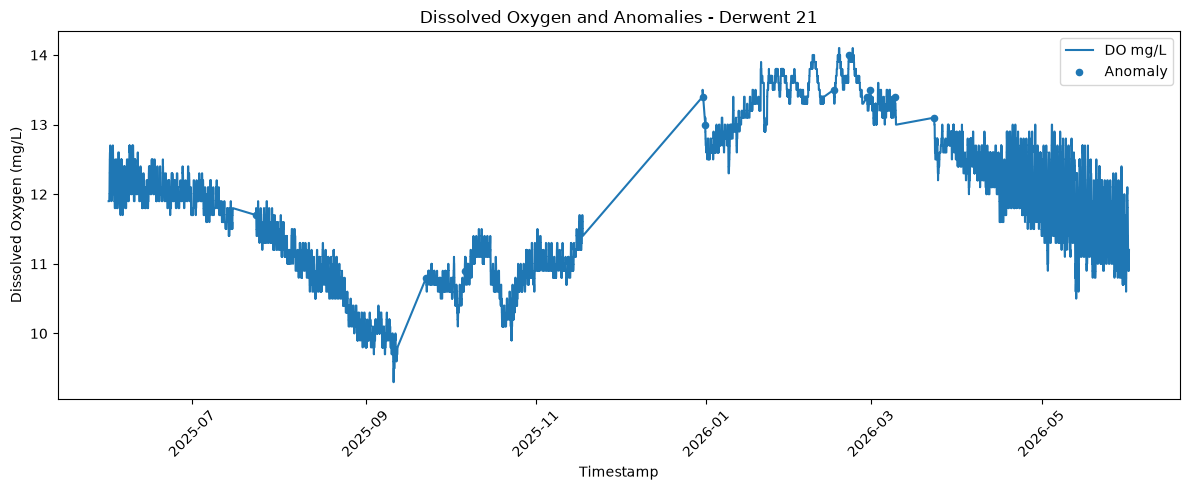

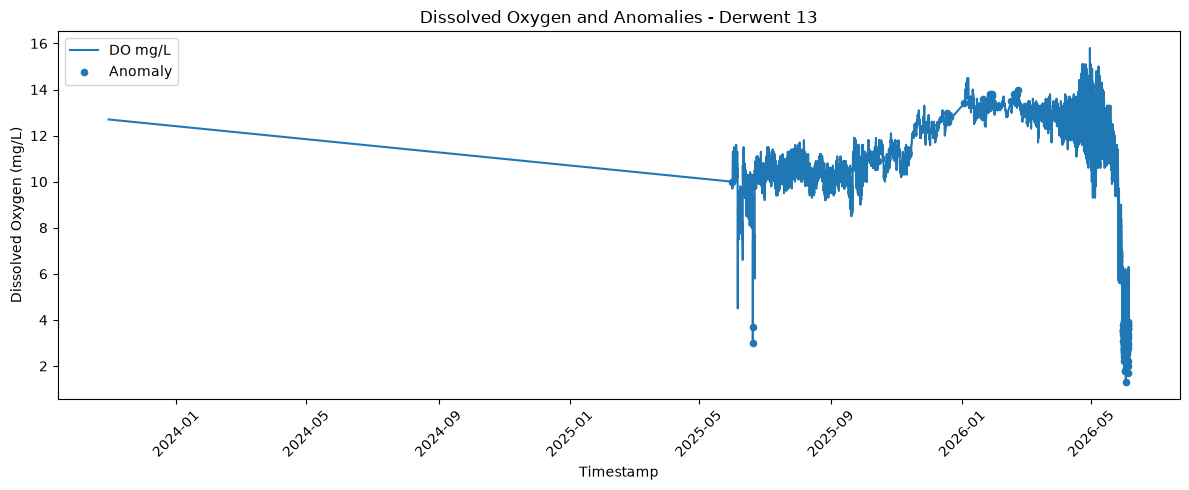

In [11]:
for sensor in df["sensor_name"].unique():
    sensor_df = df[df["sensor_name"] == sensor].copy()
    anomaly_df = sensor_df[sensor_df["anomaly_type"] != 0]

    plt.figure(figsize=(12, 5))
    plt.plot(sensor_df["timestamp"], sensor_df["dissolved_oxygen_mgl"], label="DO mg/L")
    plt.scatter(
        anomaly_df["timestamp"],
        anomaly_df["dissolved_oxygen_mgl"],
        s=20,
        label="Anomaly"
    )
    plt.xlabel("Timestamp")
    plt.ylabel("Dissolved Oxygen (mg/L)")
    plt.title(f"Dissolved Oxygen and Anomalies - {sensor}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [12]:
anomaly_records = df[df["anomaly_type"] != 0].copy()

anomaly_records = anomaly_records[
    [
        "timestamp",
        "sensor_id",
        "sensor_name",
        "dissolved_oxygen_mgl",
        "dissolved_oxygen_pct",
        "pollution_alert",
        "anomaly_type",
        "anomaly_label",
    ]
]

anomaly_records.head(20)

,timestamp,sensor_id,sensor_name,dissolved_oxygen_mgl,dissolved_oxygen_pct,pollution_alert,anomaly_type,anomaly_label
2048,2025-06-18 08:18:21,941115,Derwent 13-50,6.9,65.2,0,2,Possible Battery or Communication Gap
2065,2025-06-18 16:34:11,941115,Derwent 13-50,6.3,63.6,0,2,Possible Battery or Communication Gap
2097,2025-06-18 20:58:13,941115,Derwent 13-50,6.1,60.4,0,2,Possible Battery or Communication Gap
2514,2025-06-25 17:17:56,941115,Derwent 13-50,10.2,100.2,0,2,Possible Battery or Communication Gap
9686,2025-08-25 15:50:19,941115,Derwent 13-50,10.0,101.8,0,2,Possible Battery or Communication Gap
9720,2025-08-27 23:38:49,941115,Derwent 13-50,9.2,89.3,0,2,Possible Battery or Communication Gap
10037,2025-09-21 16:48:56,941115,Derwent 13-50,10.8,97.8,0,2,Possible Battery or Communication Gap
10052,2025-09-21 18:09:50,941115,Derwent 13-50,10.8,98.5,0,2,Possible Battery or Communication Gap
12770,2025-10-14 10:15:59,941115,Derwent 13-50,10.5,95.9,0,2,Possible Battery or Communication Gap
17325,2025-11-22 23:34:08,941115,Derwent 13-50,11.6,95.4,0,2,Possible Battery or Communication Gap


In [13]:
anomaly_records.to_csv(ANOMALY_OUTPUT, index=False)

print("Anomaly results saved to:")
print(ANOMALY_OUTPUT)

print("Number of anomaly records:", len(anomaly_records))

Anomaly results saved to:
../data/processed/anomaly_detection_results.csv
Number of anomaly records: 308


## Summary

This notebook identified and summarised anomaly patterns in the AquaSensor dissolved oxygen dataset.

The analysis used the `pollution_alert` and `anomaly_type` features created during preprocessing.

Anomaly categories included:

- Normal readings
- Possible biofouling or isolated low dissolved oxygen
- Possible sensor battery/power or communication issue
- Possible pollution event affecting multiple sensors

The anomaly records were saved to:

`data/processed/anomaly_detection_results.csv`